Importamos librerías necesarias.

In [33]:
import wfdb
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Vamos a crear e importar la base de datos de MIT-BIH en carpeta "data"

In [34]:
data_folder = os.path.join("..", "data")
db_dir = os.path.join(data_folder, "mitdb_data")
os.makedirs(db_dir, exist_ok=True)

if not os.listdir(db_dir):
    print("Downloading the MIT-BIH Arrhythmia Database...")
    wfdb.dl_database('mitdb', dl_dir=db_dir)
    print("Download completed.")
else: 
    print("Database already exists, skipping download.")

Database already exists, skipping download.


Vamos a ver los datos del paciente 100 (por ejemplo)

In [35]:
patient_100 = wfdb.rdrecord(db_dir + "/100")
p_signal_100 = patient_100.p_signal
print("Let's see the value of the leads of the patient 100: ", "\n", p_signal_100)

print("We can now separate the values of each channel:")
reshaped_p_signal = np.reshape(p_signal_100, shape = (2, 650000), copy = True)
channel_1 = reshaped_p_signal[0]
channel_2 = reshaped_p_signal[1]
channel_names = patient_100.sig_name
print("The leads were: " , channel_names,"\n", "Channel 1: ", channel_1, "\n" , "Channel 2: " , channel_2)


Let's see the value of the leads of the patient 100:  
 [[-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 ...
 [-0.675 -0.365]
 [-0.765 -0.335]
 [-1.28   0.   ]]
We can now separate the values of each channel:
The leads were:  ['MLII', 'V5'] 
 Channel 1:  [-0.145 -0.065 -0.145 ... -0.19  -0.355 -0.205] 
 Channel 2:  [-0.355 -0.225 -0.36  ... -0.335 -1.28   0.   ]


Dividimos el dataset en este caso 80/20. No hemos usado train_test_split porque queremos coger muestras significativas de arritmias y latidos normales para que nuestro modelo aprenda bien todo y creamos el diccionario según el aami para clasificacion de latidos

In [36]:
patients_train = [
    '101', '102', '104', '105', '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '118', '121', '122', '123', '200', '202',
    '203', '205', '208', '209', '210', '212', '213', '215', '217', '220',
    '221', '222', '223', '228', '230', '231', '233', '234'
]

patients_test = ['100', '103', '111', '119', '124', '201', '207', '214', '219', '232']

aami_classes = {
    "N":0, "L":0, "R": 0, "e":0, "j":0, #class 0: normal beat
    "A":1, "a":1, "J":1, "S":1,         #class 1: supraventricular ectopic beat
    "V":2, "E":2,                       #class 2: ventricular ectopic beat
    "F":3,                              #class 3: fusion beat
    "/":4, "f":4, "Q":4                 #class 4: unknown beat
}

creamos una función para sacar toda la información relevante de cada uno de los latidos y vamos a contar el número de latidos de cada categoria con Counter, esto nos será útil más adelante
Resampleamos a 250hz para que coincida con la frecuencia de la base de datos QTDB.

In [37]:
from collections import Counter
from scipy.signal import resample

total_Counts = Counter()

def beats_extraction(patient_list, dir=db_dir):
    X_total = []
    y_total = []
    fs_target = 250
    
    for patient in patient_list:
        record_path = os.path.join(dir, patient)
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')
        
        num_samples = int(len(record.p_signal) * fs_target / record.fs)
        signal_resampled = resample(record.p_signal, num_samples)
        
        resample_factor = fs_target / record.fs
        radius = 250
        
        for i in range(len(annotation.sample)):
            r_peak_resampled = int(annotation.sample[i] * resample_factor)
            symbol = annotation.symbol[i]
            
            if symbol in aami_classes:
                if r_peak_resampled - radius >= 0 and r_peak_resampled + radius < len(signal_resampled):
                    beat = signal_resampled[r_peak_resampled - radius : r_peak_resampled + radius]
                    X_total.append(beat)
                    y_total.append(aami_classes[symbol])
                
    return np.array(X_total), np.array(y_total)

for patient in patients_train + patients_test:
    record_path = os.path.join(db_dir, patient)
    annotation = wfdb.rdann(record_path, 'atr')
    total_Counts.update(annotation.symbol)

npy_dir = os.path.join(data_folder, "npy_data_mitbih")

if not os.path.exists(npy_dir):
    print("Creating npy_dir folder")
    os.makedirs(npy_dir)
    X_train, y_train = beats_extraction(patients_train)
    X_test, y_test   = beats_extraction(patients_test)
    np.save(os.path.join(npy_dir, "X_train_mitbih.npy"), X_train)
    np.save(os.path.join(npy_dir, "y_train_mitbih.npy"), y_train)
    np.save(os.path.join(npy_dir, "X_test_mitbih.npy"),  X_test)
    np.save(os.path.join(npy_dir, "y_test_mitbih.npy"),  y_test)
    print("Data saved.")
else:
    print("Data already exists, loading from disk...")
    X_train = np.load(os.path.join(npy_dir, "X_train_mitbih.npy"))
    y_train = np.load(os.path.join(npy_dir, "y_train_mitbih.npy"))
    X_test  = np.load(os.path.join(npy_dir, "X_test_mitbih.npy"))
    y_test  = np.load(os.path.join(npy_dir, "y_test_mitbih.npy"))

Data already exists, loading from disk...


In [38]:
X_train_check = np.load("../data/npy_data_mitbih/X_train_mitbih.npy")
print(f"Forma del arreglo: {X_train_check.shape}")

muestras_por_latido = X_train_check.shape[1]

print(f"La frecuencia tras el resampleo (entre los dos canales): {muestras_por_latido}")

Forma del arreglo: (89289, 500, 2)
La frecuencia tras el resampleo (entre los dos canales): 500


Vemos el número total de símbolos y filtramos por los más relevantes

Count of each symbol:  
 Counter({'N': 75052, 'L': 8075, 'R': 7259, 'V': 7130, '/': 7028, 'A': 2546, '+': 1291, 'f': 982, 'F': 803, '~': 616, '!': 472, '"': 437, 'j': 229, 'x': 193, 'a': 150, '|': 132, 'E': 106, 'J': 83, 'Q': 33, 'e': 16, '[': 6, ']': 6, 'S': 2})
We are going to filter the most relevant symbols of each aami class(N, S, V, F, Q).


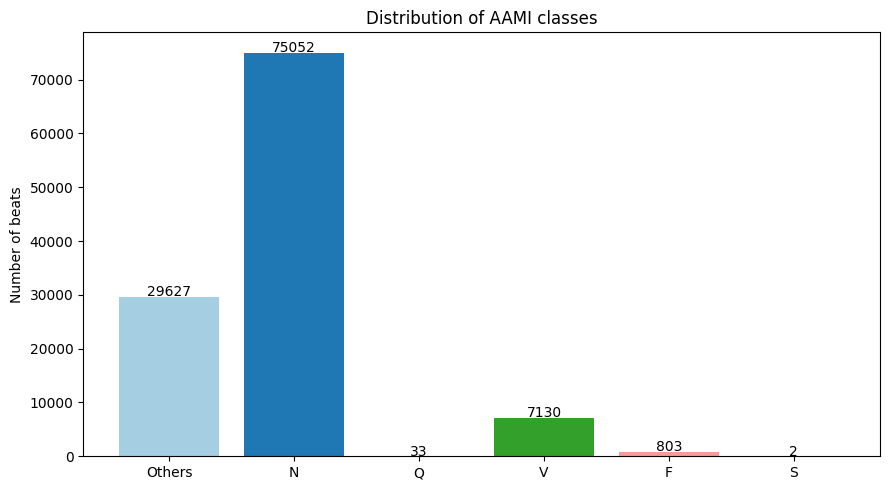

In [39]:
print("Count of each symbol: " , "\n" , total_Counts)

print("We are going to filter the most relevant symbols of each aami class(N, S, V, F, Q).")
relevant_symbols = ['N', 'S', 'V', 'F', 'Q'] 

filtrated_counts = {}
others_sum = 0

for symbol, quantity in total_Counts.items():
    if symbol in relevant_symbols:
        filtrated_counts[symbol] = quantity
    else:
        others_sum += quantity
        filtrated_counts['Others'] = others_sum

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(filtrated_counts.keys(), filtrated_counts.values(), color=plt.cm.Paired(range(len(filtrated_counts))))

for bar, value in zip(bars, filtrated_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, str(value), ha='center')

ax.set_title('Distribution of AAMI classes')
ax.set_ylabel('Number of beats')
plt.tight_layout()
plt.show()

Se puede observar que tenemos muchos latidos normales en comparación al resto. Esto es un problema de desbalance que solucionaremos más adelante